In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2014-01-01'
end = '2024-03-11'
stock = 'TCS.NS'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [3]:
data

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2014-01-01,811.153503,822.906603,810.324776,821.249149,529952
2014-01-02,816.314270,824.601725,812.227011,815.937568,1726948
2014-01-03,837.107910,839.707211,808.874089,815.447526,2618174
2014-01-06,843.662842,845.320296,827.615281,839.669759,2311810
2014-01-07,831.062012,850.010162,828.368626,843.813425,2897486
...,...,...,...,...,...
2024-03-01,3839.725586,3882.536556,3832.645069,3851.776546,2043265
2024-03-04,3826.924316,3861.810831,3822.422779,3849.713164,1749271


In [4]:
data.reset_index(inplace=True)

In [5]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2014-01-01,811.153503,822.906603,810.324776,821.249149,529952
1,2014-01-02,816.314270,824.601725,812.227011,815.937568,1726948
2,2014-01-03,837.107910,839.707211,808.874089,815.447526,2618174
3,2014-01-06,843.662842,845.320296,827.615281,839.669759,2311810
4,2014-01-07,831.062012,850.010162,828.368626,843.813425,2897486
...,...,...,...,...,...,...
2507,2024-03-01,3839.725586,3882.536556,3832.645069,3851.776546,2043265
2508,2024-03-04,3826.924316,3861.810831,3822.422779,3849.713164,1749271
2509,2024-03-05,3762.590576,3811.262862,3732.486760,3809.387241,2070859


In [6]:
ma_100_days = data.Close.rolling(100).mean()

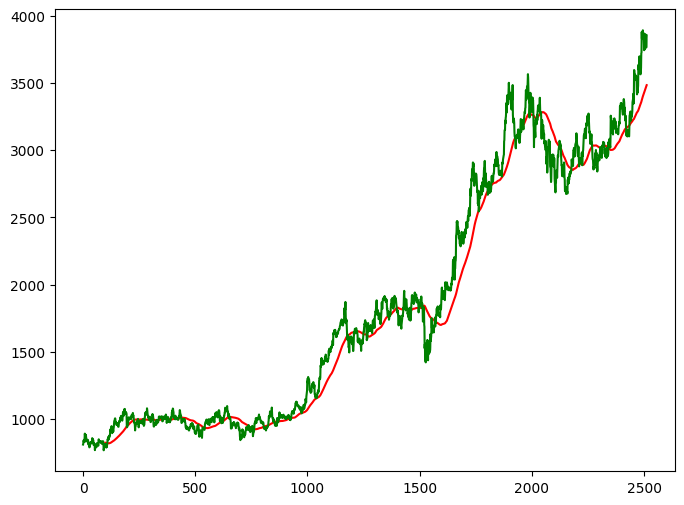

In [7]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [8]:
ma_200_days = data.Close.rolling(200).mean()

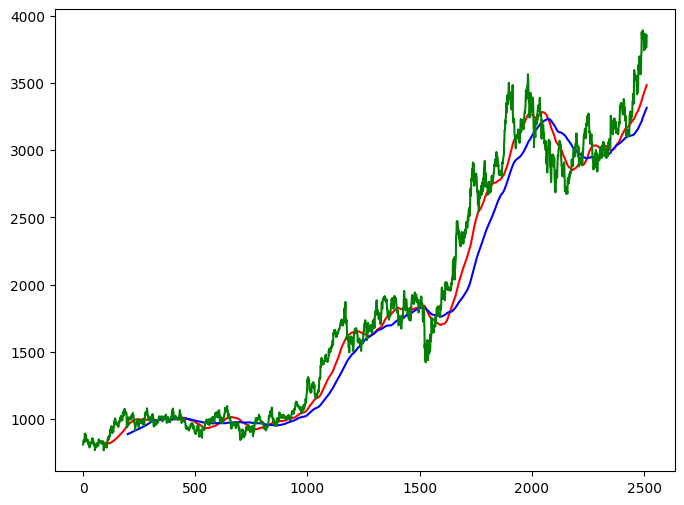

In [9]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [10]:
data.dropna(inplace=True)

In [11]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [12]:
data_train.shape[0]

2009

In [13]:
data_test.shape[0]

503

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [15]:
data_train_scale = scaler.fit_transform(data_train)

In [16]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [17]:
x, y = np.array(x), np.array(y)

In [18]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [19]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

c:\Users\Vatsal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [21]:
model.fit(x,y, epochs = 100, batch_size =32, verbose =1)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - loss: 0.0330
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0055
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.0058
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - loss: 0.0047
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - loss: 0.0048
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - loss: 0.0041
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - loss: 0.0036
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - loss: 0.0037
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - loss: 0.0036
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - loss: 0.0041
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - loss: 0.0035
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - loss: 0.0035
Epoch 13/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - loss: 0.0042
Epoch 14/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - loss: 0.0036
Epoch 15/100
60/60 ━━━━━━━━━━━━━

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [23]:
pas_100_days = data_train.tail(100)

In [24]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [25]:
data_test_scale  =  scaler.fit_transform(data_test)

In [26]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [27]:
y_predict = model.predict(x)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step


In [28]:
scale =1/scaler.scale_

In [29]:
y_predict = y_predict*scale

In [30]:
y = y*scale

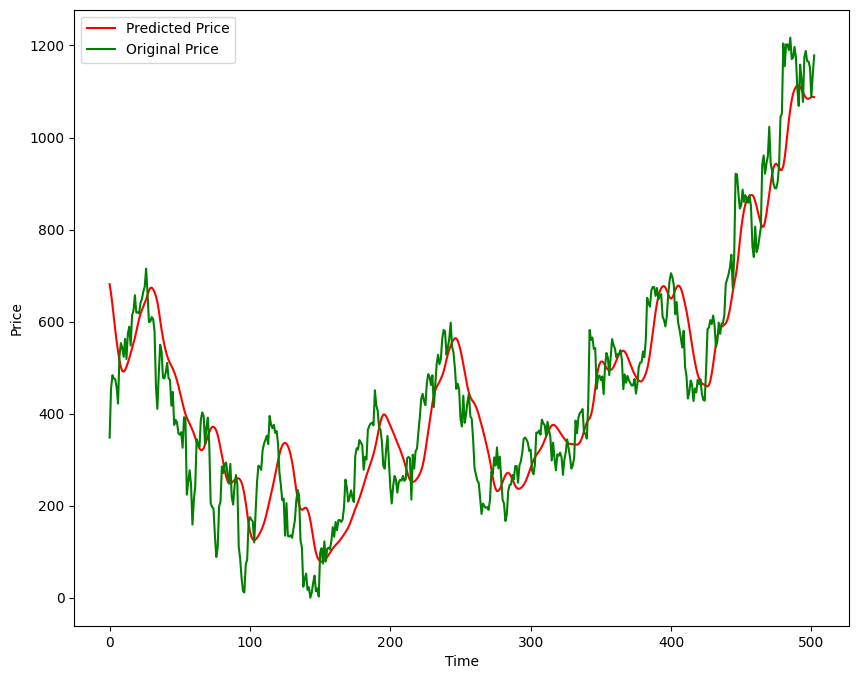

In [31]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [32]:
model.save('Stock Prediction Model.keras')

In [33]:
pip install --upgrade streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
!pip show streamlit

Name: streamlit
Version: 1.55.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License: 
Location: C:\Users\Vatsal\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: altair, blinker, cachetools, click, gitpython, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, requests, tenacity, toml, tornado, typing-extensions, watchdog
Required-by: 
